# 1. Data Structure & Stability Analysis
This notebook covers:
- Loading AllenSDK Session Data
- Constructing Neural Response Matrices
- Basic PCA Visualization
- **Latent Variable Stability Analysis (CCA)**: Intra-Probe & Inter-Probe

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA

# Import custom style module
import sys
sys.path.append(os.path.dirname(os.path.abspath(''))) # Ensure we can import from current dir
import viz_style
viz_style.set_architectural_style()

# Setup Plotting
%matplotlib inline

Architectural plot style applied (Fonts: Roboto, Kozuka, Helvetica).


In [30]:
# Load Data
output_dir = "../Dataset/RAW"
manifest_path = os.path.join(output_dir, "manifest.json")
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)

session_id = 750749662
print(f"Loading Session {session_id}...")
session = cache.get_session_data(session_id)
print("Session loaded.")

Loading Session 750749662...
Session loaded.
Session loaded.


In [31]:
# Construct Response Matrix (Natural Movie One)
stimulus_name = "natural_movie_one"
movie_table = session.get_stimulus_table(stimulus_name)
frame_duration = movie_table['duration'].mean()

print("Calculating spike counts for VISp units...")
# Filter for VISp units
units = session.units[session.units.ecephys_structure_acronym == 'VISp']
print(f"Selected {len(units)} VISp units.")

spike_counts = session.presentationwise_spike_counts(
    stimulus_presentation_ids=movie_table.index.values,
    bin_edges=np.array([0, frame_duration]),
    unit_ids=units.index.values
)

# Sum spikes (Frames x Neurons)
response_matrix_all = spike_counts.sum(dim="time_relative_to_stimulus_onset")

# Create DataFrame
df_response = pd.DataFrame(
    response_matrix_all.values,
    index=movie_table.index,
    columns=units.index
)
df_response['frame'] = movie_table['frame']

# Average across repeats
average_response_matrix_total = df_response.groupby('frame').mean()
print(f"Average Response Matrix Shape: {average_response_matrix_total.shape}")

Calculating spike counts for VISp units...
Selected 52 VISp units.
Selected 52 VISp units.
Average Response Matrix Shape: (900, 52)
Average Response Matrix Shape: (900, 52)


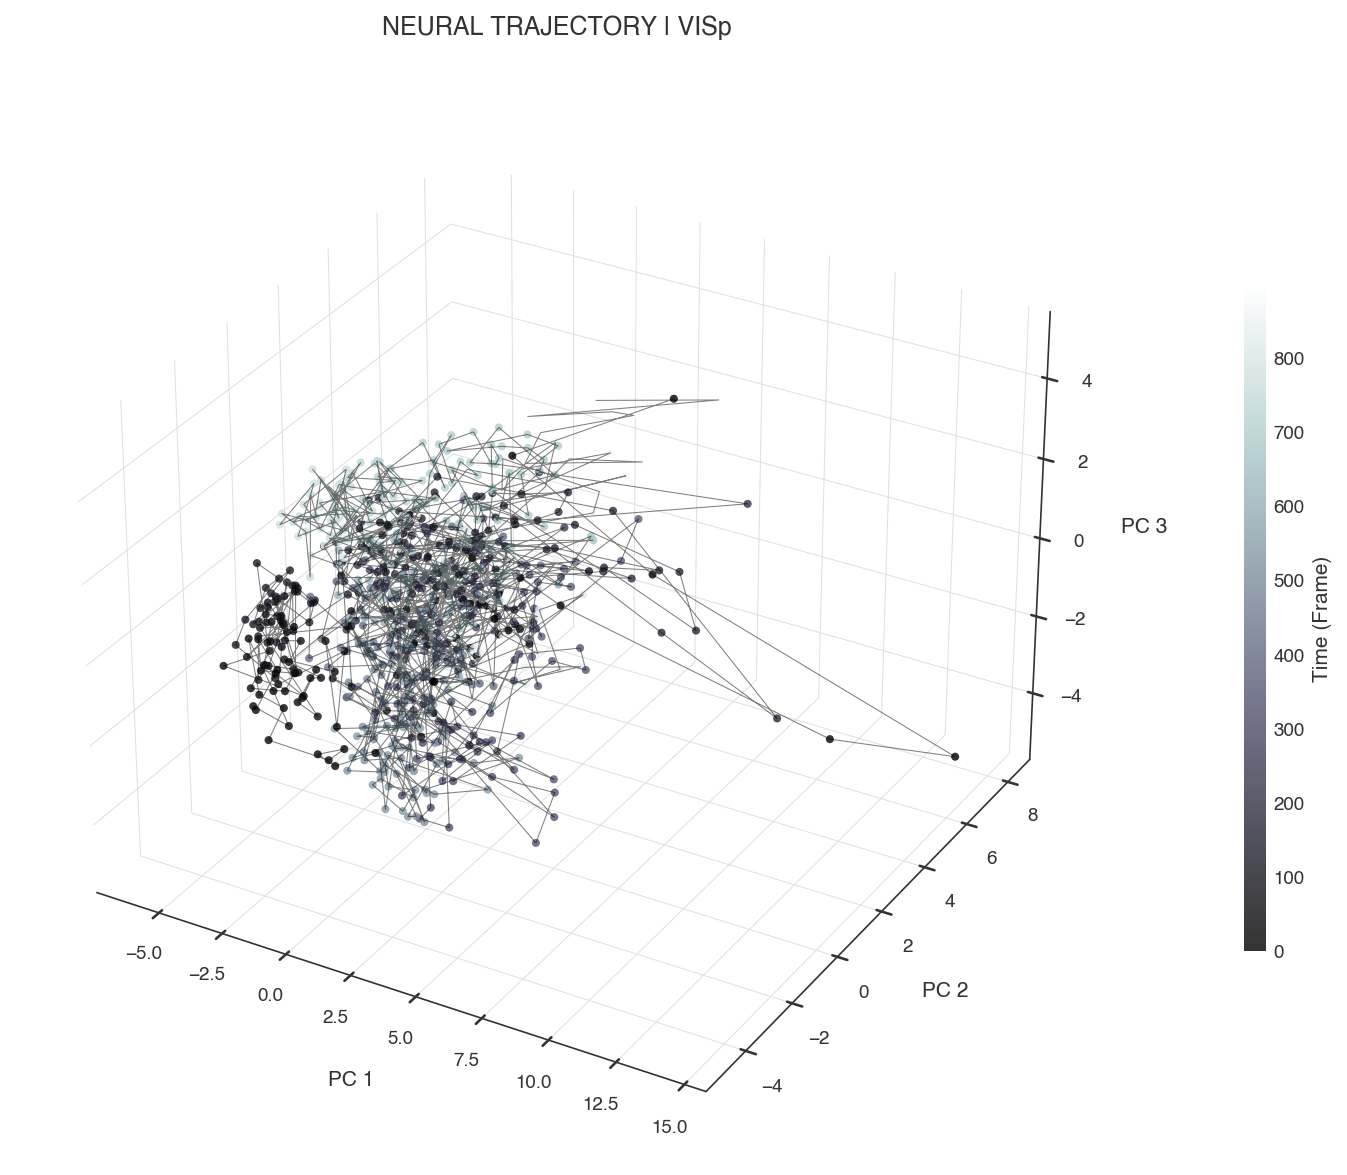

In [32]:
# Basic PCA Visualization
X = average_response_matrix_total.values
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Architectural 3D Style
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('w')
ax.yaxis.pane.set_edgecolor('w')
ax.zaxis.pane.set_edgecolor('w')
ax.grid(True, linestyle=':', linewidth=0.5, color='#CCCCCC')

# Plot with a technical gradient (Time)
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=np.arange(len(X)), cmap='bone', s=15, alpha=0.8, edgecolors='none')

# Connect points with a thin line to show trajectory
ax.plot(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], color='black', linewidth=0.5, alpha=0.5)

ax.set_title("NEURAL TRAJECTORY | VISp", pad=20)
ax.set_xlabel("PC 1", labelpad=10)
ax.set_ylabel("PC 2", labelpad=10)
ax.set_zlabel("PC 3", labelpad=10)

# Minimalist Colorbar
cbar = plt.colorbar(sc, label="Time (Frame)", shrink=0.6, aspect=30, pad=0.1)
cbar.outline.set_visible(False)
cbar.ax.tick_params(size=0)

plt.tight_layout()
plt.show()

Loadings Shape: (52, 10)
Units in Matrix: 52

=== Top 10 Units for PC1 ===


,PC1,ecephys_structure_acronym,probe_vertical_position,probe_id
unit_id,,,,
951878498,0.267586,VISp,2760,769322806
951878103,0.245931,VISp,2660,769322806
951878236,0.237675,VISp,2700,769322806
951878022,0.233241,VISp,2620,769322806
951878800,0.225959,VISp,2880,769322806
951878379,0.222935,VISp,2780,769322806
951878000,0.218626,VISp,2620,769322806
951878821,0.216930,VISp,2880,769322806
951878743,0.212184,VISp,2840,769322806


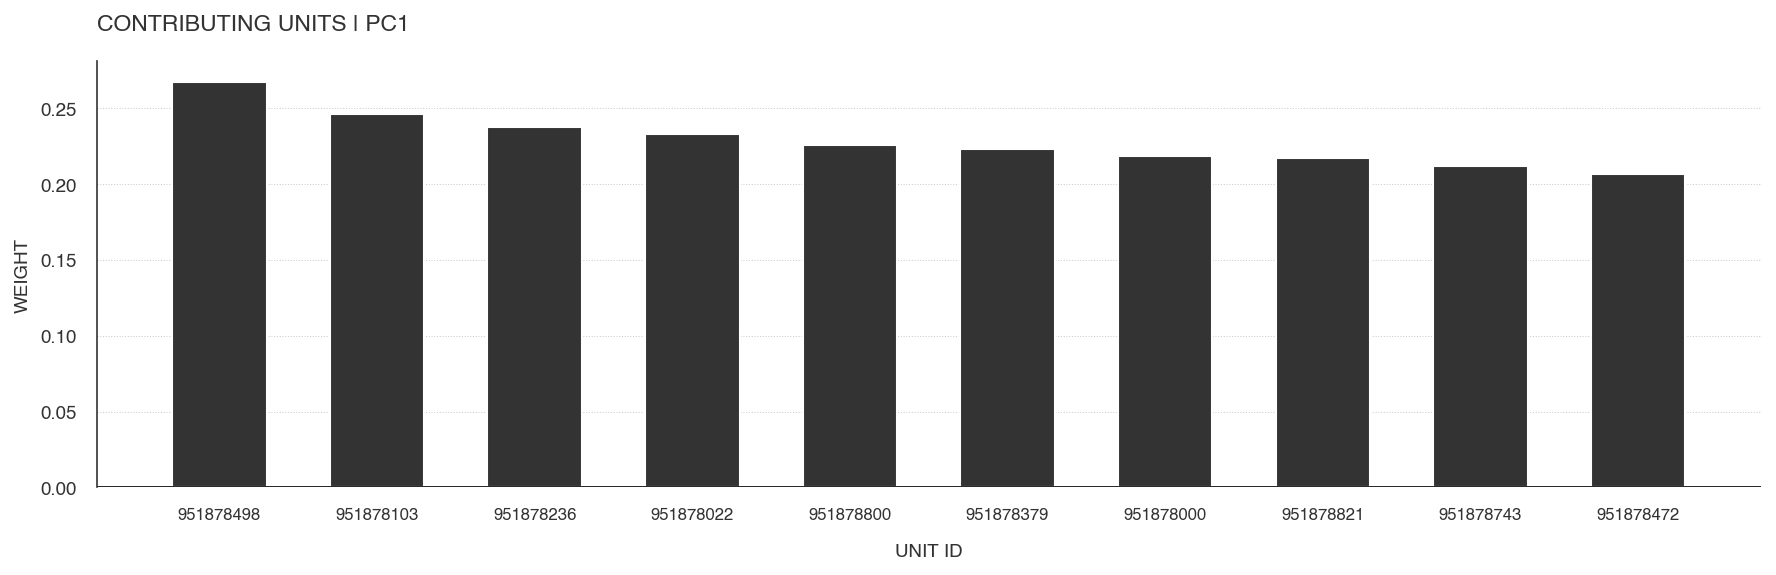

Region Composition (Top 10):
VISp    10
Name: ecephys_structure_acronym, dtype: int64

=== Top 10 Units for PC2 ===


,PC2,ecephys_structure_acronym,probe_vertical_position,probe_id
unit_id,,,,
951878032,0.284859,VISp,2620,769322806
951878800,0.267049,VISp,2880,769322806
951878821,0.258456,VISp,2880,769322806
951877575,-0.256233,VISp,2460,769322806
951878092,-0.245215,VISp,2660,769322806
951877651,-0.243576,VISp,2460,769322806
951878011,0.234017,VISp,2620,769322806
951877505,-0.232712,VISp,2440,769322806
951878022,-0.230226,VISp,2620,769322806


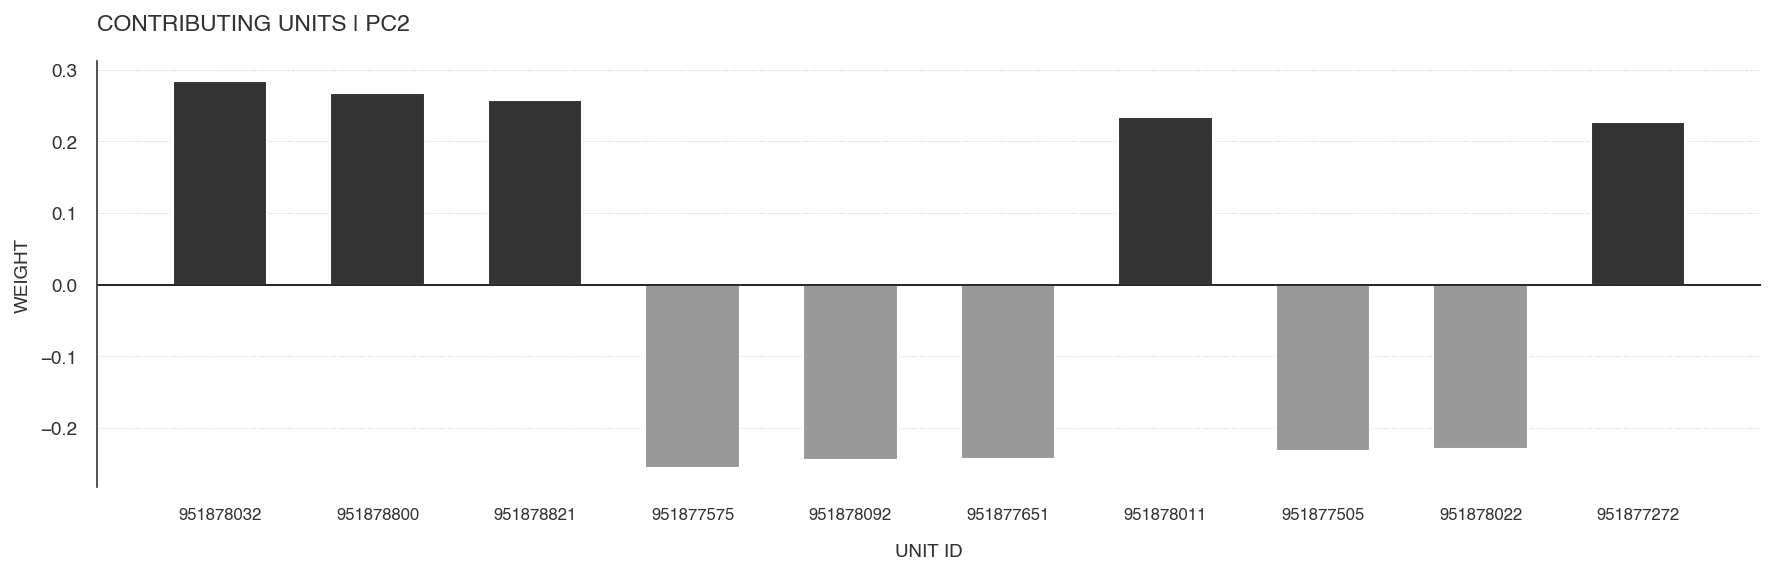

Region Composition (Top 10):
VISp    10
Name: ecephys_structure_acronym, dtype: int64

=== Top 10 Units for PC3 ===


,PC3,ecephys_structure_acronym,probe_vertical_position,probe_id
unit_id,,,,
951878134,0.379458,VISp,2680,769322806
951877260,0.301748,VISp,2340,769322806
951878167,-0.296509,VISp,2680,769322806
951877753,-0.263387,VISp,2520,769322806
951877765,0.250104,VISp,2540,769322806
951877777,0.213437,VISp,2540,769322806
951877790,-0.206876,VISp,2540,769322806
951878331,0.182947,VISp,2720,769322806
951878511,-0.179773,VISp,2760,769322806


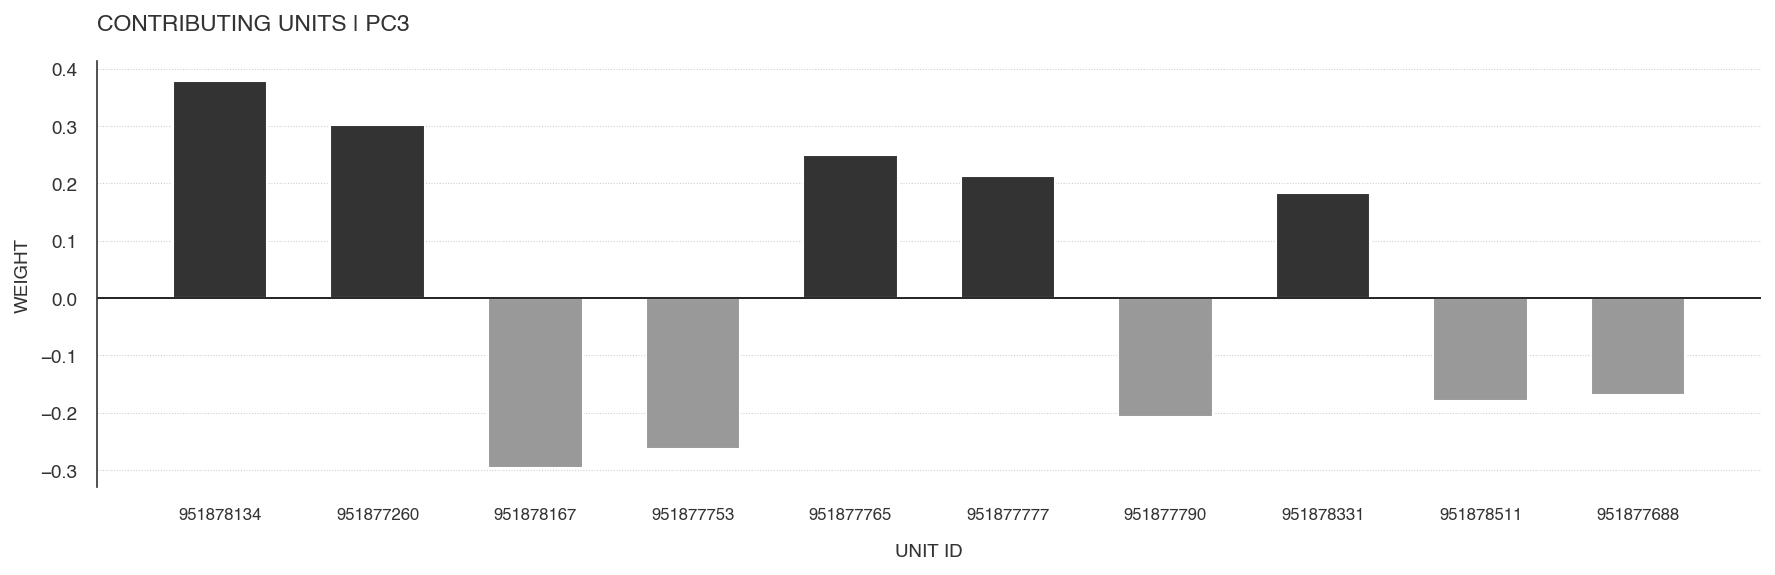

Region Composition (Top 10):
VISp    10
Name: ecephys_structure_acronym, dtype: int64


In [33]:
# %% [markdown]
# ## PCA Loadings Analysis (Unit Contribution)
# We analyze the contribution (weight) of each unit to the top 3 Principal Components.
# - **High Absolute Weight**: The unit strongly influences the neural trajectory along this component.
# - **Positive/Negative Sign**: Indicates the direction of the relationship.

# %%
# Re-run PCA on the current full matrix to ensure shapes match
# This prevents "Shape of passed values is (X, Y), indices imply (Z, Y)" errors
X = average_response_matrix_total.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca_full = PCA(n_components=10) # Use a new PCA object
pca_full.fit(X_scaled)

# Get PCA Loadings (Weights)
# pca.components_ shape: (n_components, n_features)
loadings = pca_full.components_.T # Shape: (n_units, n_components)
n_pcs = loadings.shape[1]

print(f"Loadings Shape: {loadings.shape}")
print(f"Units in Matrix: {len(average_response_matrix_total.columns)}")

# Create DataFrame for Loadings
df_loadings = pd.DataFrame(
    loadings,
    index=average_response_matrix_total.columns,
    columns=[f"PC{i+1}" for i in range(n_pcs)]
)

# Add Unit Metadata (Structure, Probe)
# Ensure 'units' is the DataFrame (it might have been overwritten in previous cells)
units_df = session.units 

# We join with the 'units' table to get anatomical info
df_loadings = df_loadings.join(units_df[['ecephys_structure_acronym', 'probe_id', 'probe_vertical_position']])

# Function to show top units for a PC
def show_top_units(pc_name, top_n=10):
    print(f"\n=== Top {top_n} Units for {pc_name} ===")
    
    # Sort by absolute weight to find most influential units (regardless of sign)
    sorted_df = df_loadings.reindex(df_loadings[pc_name].abs().sort_values(ascending=False).index)
    
    top_units = sorted_df.head(top_n)
    
    # Display Table
    display(top_units[[pc_name, 'ecephys_structure_acronym', 'probe_vertical_position', 'probe_id']])
    
    # Plot weights - Architectural Style
    plt.figure(figsize=(12, 4))
    
    # Use black/gray for positive/negative to keep it monochromatic but distinct
    colors = ['#333333' if x >= 0 else '#999999' for x in top_units[pc_name]]
    
    bars = plt.bar(range(top_n), top_units[pc_name], color=colors, width=0.6)
    
    # Clean up axes
    plt.axhline(0, color='black', linewidth=0.8)
    plt.xticks(range(top_n), [f"{uid}" for uid in top_units.index], rotation=0, fontsize=8)
    plt.xlabel("UNIT ID", fontsize=9, labelpad=10)
    plt.ylabel("WEIGHT", fontsize=9)
    plt.title(f"CONTRIBUTING UNITS | {pc_name}", loc='left', fontsize=11, pad=15)
    
    # Remove spines
    sns.despine(bottom=True)
    plt.grid(axis='y', linestyle=':', linewidth=0.5, color='#CCCCCC')
    
    plt.tight_layout()
    plt.show()
    
    # Region Summary
    print(f"Region Composition (Top {top_n}):")
    print(top_units['ecephys_structure_acronym'].value_counts())

# Analyze PC1, PC2, PC3
for i in range(3):
    show_top_units(f"PC{i+1}")

--- Intra-Probe Stability (VISp Only) ---


probeC: 0.8492

--- Inter-Probe Similarity (VISp Only) ---


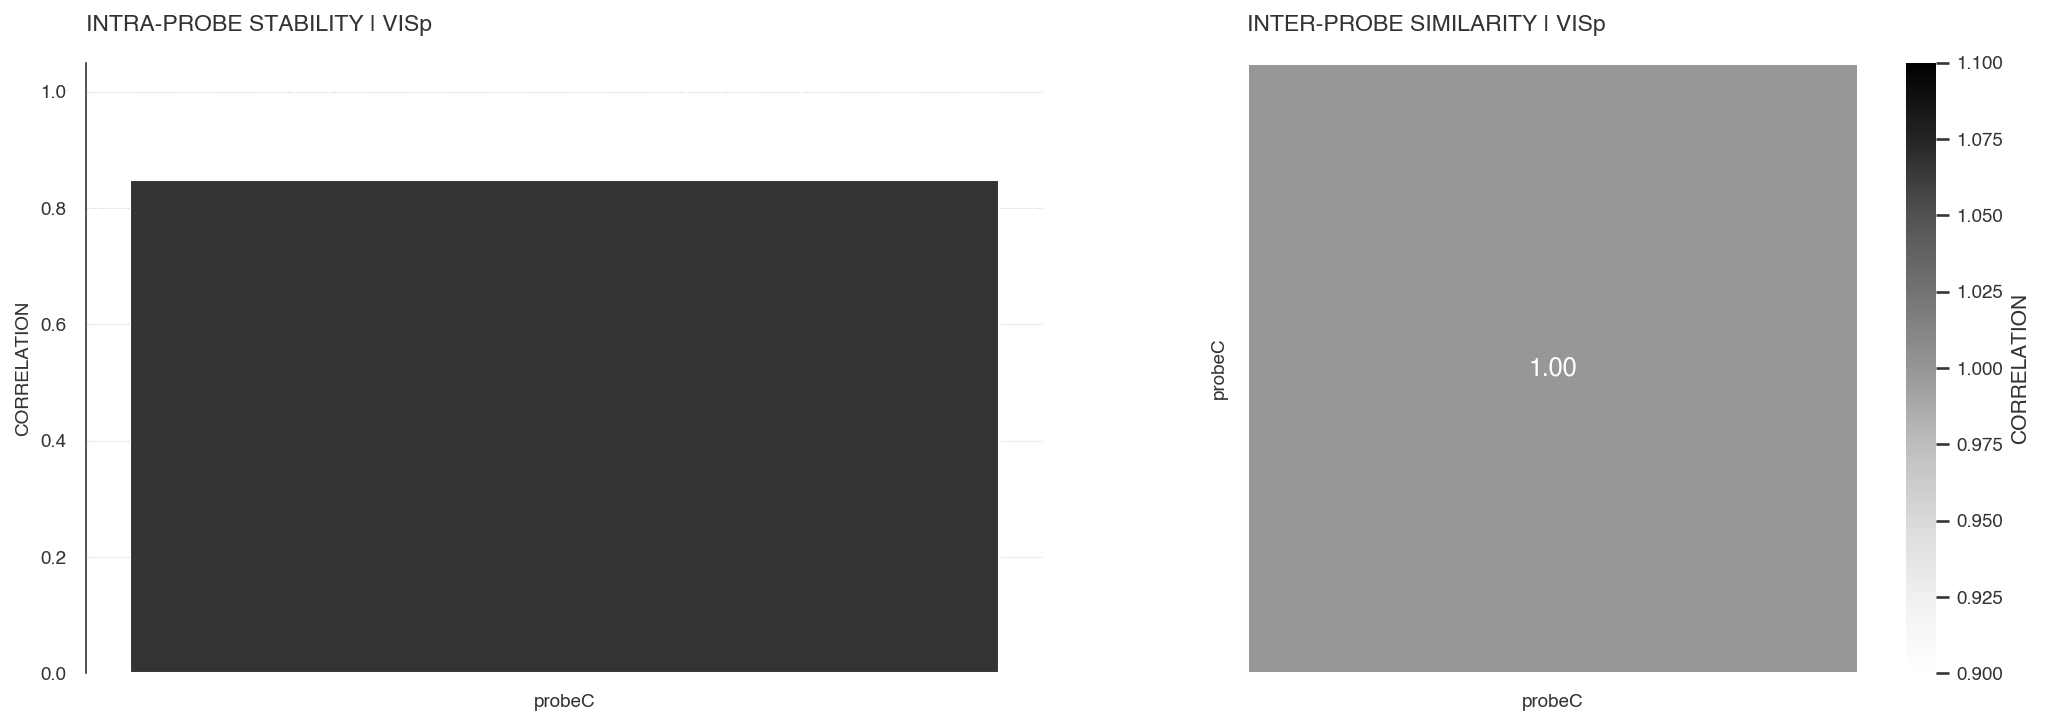

In [34]:
# CCA Stability Analysis Function
def analyze_latent_stability(session, unit_ids, stimulus_name="natural_movie_one", n_components_pca=10, n_components_cca=3):
    stim_table = session.get_stimulus_table(stimulus_name)
    frame_duration = stim_table['duration'].mean()
    
    spike_counts = session.presentationwise_spike_counts(
        stimulus_presentation_ids=stim_table.index.values,
        bin_edges=np.array([0, frame_duration]),
        unit_ids=unit_ids
    )
    
    X_all = spike_counts.sum(dim="time_relative_to_stimulus_onset").values
    n_frames = 900
    n_repeats = len(stim_table) // n_frames
    n_units = X_all.shape[1]
    
    X_reshaped = X_all.reshape(n_repeats, n_frames, n_units)
    
    # Split-Half (First 5 vs Last 5)
    half = n_repeats // 2
    X_A = X_reshaped[:half].mean(axis=0)
    X_B = X_reshaped[half:].mean(axis=0)
    
    pca_A = PCA(n_components=n_components_pca)
    pca_B = PCA(n_components=n_components_pca)
    
    P_A = pca_A.fit_transform(StandardScaler().fit_transform(X_A))
    P_B = pca_B.fit_transform(StandardScaler().fit_transform(X_B))
    
    cca = CCA(n_components=n_components_cca)
    cca.fit(P_A, P_B)
    U_c, V_c = cca.transform(P_A, P_B)
    
    corrs = [np.corrcoef(U_c[:, i], V_c[:, i])[0, 1] for i in range(n_components_cca)]
    return corrs

# Multi-Probe Analysis (Restricted to VISp)
probe_units_dict = {}
for probe_id, row in session.probes.iterrows():
    probe_name = row['description']
    # Filter for VISp units on this probe
    units = session.units[(session.units.probe_id == probe_id) & (session.units.ecephys_structure_acronym == 'VISp')]
    if len(units) > 5: # Lower threshold as we are filtering
        probe_units_dict[probe_name] = units.index.values

# 1. Intra-Probe Stability
print("--- Intra-Probe Stability (VISp Only) ---")
stability_scores = {}
for name, units in probe_units_dict.items():
    try:
        corrs = analyze_latent_stability(session, units)
        stability_scores[name] = corrs[0]
        print(f"{name}: {corrs[0]:.4f}")
    except Exception as e:
        print(f"Could not analyze {name}: {e}")
        stability_scores[name] = 0

# 2. Inter-Probe Similarity
print("\n--- Inter-Probe Similarity (VISp Only) ---")
probe_names = sorted(probe_units_dict.keys())
n_probes = len(probe_names)
similarity_matrix = np.zeros((n_probes, n_probes))
probe_trajectories = {}

for name in probe_names:
    units = probe_units_dict[name]
    # Ensure units are in the main matrix (which is already VISp filtered)
    valid_units = [u for u in units if u in average_response_matrix_total.columns]
    
    if len(valid_units) < 3:
        print(f"Skipping {name} (not enough valid units)")
        probe_trajectories[name] = None
        continue

    X_probe = average_response_matrix_total[valid_units].values
    pca = PCA(n_components=min(10, len(valid_units)))
    probe_trajectories[name] = pca.fit_transform(StandardScaler().fit_transform(X_probe))

cca = CCA(n_components=1)
for i, name_i in enumerate(probe_names):
    for j, name_j in enumerate(probe_names):
        if i == j:
            similarity_matrix[i, j] = 1.0
        else:
            traj_i = probe_trajectories[name_i]
            traj_j = probe_trajectories[name_j]
            
            if traj_i is not None and traj_j is not None:
                cca.fit(traj_i, traj_j)
                U, V = cca.transform(traj_i, traj_j)
                similarity_matrix[i, j] = np.corrcoef(U[:, 0], V[:, 0])[0, 1]

# Plot - Architectural Style
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Chart
axes[0].bar(stability_scores.keys(), stability_scores.values(), color='#333333', width=0.5)
axes[0].set_title("INTRA-PROBE STABILITY | VISp", loc='left', fontsize=11, pad=15)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("CORRELATION", fontsize=9)
axes[0].grid(axis='y', linestyle=':', linewidth=0.5, color='#CCCCCC')
sns.despine(ax=axes[0], bottom=True)

# Heatmap
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", 
            xticklabels=probe_names, yticklabels=probe_names, 
            ax=axes[1], cmap='Greys', cbar_kws={'label': 'CORRELATION'},
            square=True, linewidths=0.5, linecolor='white')
axes[1].set_title("INTER-PROBE SIMILARITY | VISp", loc='left', fontsize=11, pad=15)

plt.tight_layout()
plt.show()